In [1]:
#Load Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, mannwhitneyu, ttest_ind, chisquare
from statsmodels.stats.proportion import proportions_ztest

## **1. Business Context**

- Perusahaan melakukan pengujian onboarding flow dan paywall copy baru pada aplikasi subscription.
- Pengujian bertujuan untuk meningkatkan *trial start*, *trial to paid*, serta *30 day revenue*.
- Berdasarkan kondisi tersebut perusahaan ingin memastikan bahwa Varian B meningkatkan *trial start*, *trial to paid*, serta *30 day revenue* dibanding Varian A.
- Berdasarkan tujuan perusahaan didefinisikan 
    * Varian A : tidak menggunakan *flow + paywall* copy baru
    * Varian B : menggunakan *flow + paywall* copy baru 
- Metrik yang digunakan dalam eksperimen :
    - *trial start*
    - *trial to paid*
    - *30 day revenue*

In [2]:
#Load Data
df = pd.read_csv('ab_app_subscription (1).csv')
df

,period,cohort_date,variant,user_id,country,platform,traffic_source,device_model,age,sessions_7d,time_to_first_action_min,trial_start,paid_subscriber,revenue_30d
0,during,2025-07-05,B,APP201334,ID,android,organic,low_end,54,4,6.1,0,0,444.616527
1,during,2025-07-04,A,APP201596,ID,android,organic,low_end,24,2,6.5,0,0,424.835708
2,during,2025-07-06,A,APP200545,TH,android,organic,mid_range,41,4,7.3,0,0,393.086785
3,during,2025-07-07,B,APP203155,MY,android,organic,mid_range,40,1,2.3,0,0,502.190971
4,during,2025-07-04,A,APP202354,ID,android,paid,mid_range,49,6,2.4,1,0,432.384427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,during,2025-07-06,A,APP203295,ID,android,organic,low_end,21,3,6.1,1,1,451.623263
501,during,2025-07-10,B,APP203577,TH,android,organic,flagship,22,8,3.8,1,0,447.467872
502,during,2025-07-09,A,APP202962,ID,android,social,mid_range,34,5,6.6,1,1,324.031502
503,during,2025-07-11,A,APP207633,ID,ios,paid,low_end,48,4,3.4,0,0,375.788296


## **2. Data Preprocessing**

#### **2.1. Check Missing Value**

In [3]:
df.isnull().sum()

period                      0
cohort_date                 0
variant                     0
user_id                     0
country                     0
platform                    0
traffic_source              0
device_model                0
age                         0
sessions_7d                 0
time_to_first_action_min    0
trial_start                 0
paid_subscriber             0
revenue_30d                 0
dtype: int64

#### **2.2. Check Duplicate**

In [4]:
df.duplicated().sum()

np.int64(0)

#### **2.3. Check Unconsistency Data**

In [5]:
df.describe(include='object')

,period,cohort_date,variant,user_id,country,platform,traffic_source,device_model
count,505,505,505,505,505,505,505,505
unique,1,14,2,505,6,2,4,3
top,during,2025-07-06,A,APP201334,ID,android,organic,mid_range
freq,505,56,257,1,244,361,245,275


In [6]:
df['variant'].unique()

array(['B', 'A'], dtype=object)

In [7]:
df['country'].unique()

array(['ID', 'TH', 'MY', 'IN', 'PH', 'VN'], dtype=object)

In [8]:
df['platform'].unique()

array(['android', 'ios'], dtype=object)

In [9]:
df['traffic_source'].unique()

array(['organic', 'paid', 'social', 'referral'], dtype=object)

In [10]:
df['device_model'].unique()

array(['low_end', 'mid_range', 'flagship'], dtype=object)

#### **2.4. Check Outlier**

a. *reveneue_30d*

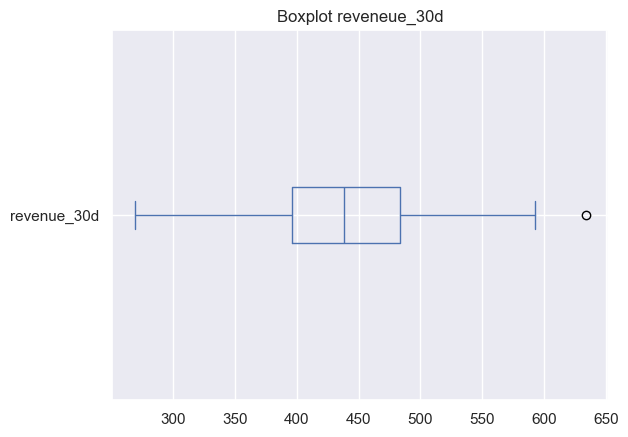

In [11]:
sns.set()
df['revenue_30d'].plot(kind='box',vert=False, color = 'b')
plt.title('Boxplot reveneue_30d')
plt.show()

In [12]:
Q1 = df['revenue_30d'].quantile(0.25)
Q3 = df['revenue_30d'].quantile(0.75)
IQR = Q3-Q1
Qmax = Q3 + (1.5)*IQR
Qmin = Q1 - (1.5)*IQR
df['revenue_30d_clean'] = df[(df['revenue_30d']>=Qmin) & (df['revenue_30d']<=Qmax)]['revenue_30d']

In [13]:
df_clean = df[(df['revenue_30d']>=Qmin) & (df['revenue_30d']<=Qmax)]
df_clean.isnull().sum()

period                      0
cohort_date                 0
variant                     0
user_id                     0
country                     0
platform                    0
traffic_source              0
device_model                0
age                         0
sessions_7d                 0
time_to_first_action_min    0
trial_start                 0
paid_subscriber             0
revenue_30d                 0
revenue_30d_clean           0
dtype: int64

#### **2.5. Memastikan bahwa sampel yang digunakan representatif**

In [14]:
sample_country = pd.crosstab(df_clean['variant'], df_clean['country'], normalize='index').round(2)
sample_country

country,ID,IN,MY,PH,TH,VN
variant,,,,,,
A,0.45,0.20,0.02,0.12,0.09,0.12
B,0.52,0.17,0.04,0.10,0.08,0.09


In [15]:
def check_sample(data, column):
    new_columns = pd.crosstab(data['variant'], data[column], normalize='index').round(2)
    return new_columns

In [16]:
pd.crosstab(df_clean['variant'], df_clean['country'], normalize='index').round(2)

country,ID,IN,MY,PH,TH,VN
variant,,,,,,
A,0.45,0.20,0.02,0.12,0.09,0.12
B,0.52,0.17,0.04,0.10,0.08,0.09


In [17]:
pd.crosstab(df_clean['variant'], df_clean['platform'], normalize='index').round(2)

platform,android,ios
variant,,
A,0.72,0.28
B,0.71,0.29


In [18]:
pd.crosstab(df_clean['variant'], df_clean['traffic_source'], normalize='index').round(2)

traffic_source,organic,paid,referral,social
variant,,,,
A,0.47,0.32,0.09,0.12
B,0.50,0.33,0.08,0.09


In [19]:
pd.crosstab(df_clean['variant'], df_clean['device_model'], normalize='index').round(2)

device_model,flagship,low_end,mid_range
variant,,,
A,0.22,0.25,0.53
B,0.17,0.26,0.56


## **3. A/B Testing**

#### **Pendefinisian Hipotesis**

Varian A : tidak menggunakan *flow + paywall* copy baru \
Varian B : menggunakan *flow + paywall* copy baru 

Tujuan perusahaan ingin mengetahui apakah varian B meningkatkan *trial_start, paid_subscribe* & *revenue_30d* dengan demikian didefinisikan
* $H_0$ : *revenue_30d* varian B $\leq$ *revenue_30d* varian A
* $H_1$ : *revenue_30d* varian B $\gt$ *revenue_30d* varian A

**Kesimpulan :** Tolak $H_0$ ketika *p-value* $\leq$ 0,05 

#### **a. trial-start**

Pada tahap ini dilakukan pengujian proporsi dikarenakan kita ingin mengetahui apakah Varian B meningkatkan jumlah trial_start (data biner 0 dan 1) dibandingkan Varian A. Hipotesis yang digunakan ialah
* $H_0$ : Tidak ada perbedaan antara Varian A dan B ($p_B - p_A = 0$).
* $H_1$ : Varian B memiliki proporsi trial_start yang lebih tinggi daripada Varian A ($p_B > p_A$).

Karena data berupa data kategorik (0 dan 1), maka digunakan Z-test. Uji ini akan menghitung apakah selisih nilai antara kedua grup cukup besar untuk dianggap signifikan secara statistik.

In [20]:
# 1. Hitung jumlah 'trial_start' (angka 1) untuk masing-masing grup
successes_a = df_clean[df_clean['variant'] == 'A']['trial_start'].sum()
successes_b = df_clean[df_clean['variant'] == 'B']['trial_start'].sum()

# 2. Hitung total sampel masing-masing grup
n_a = df_clean[df_clean['variant'] == 'A']['trial_start'].count()
n_b = df_clean[df_clean['variant'] == 'B']['trial_start'].count()

# 3. Jalankan Z-test
# alternative='larger' karena kita ingin menguji apakah B > A
stat, pval = proportions_ztest([successes_b, successes_a], [n_b, n_a], alternative='larger')

print(f'Varian A: {successes_a/n_a:.2%}')
print(f'Varian B: {successes_b/n_b:.2%}')
print(f"P-Value: {pval:.4f}")
print('---------------------------')
print('Kesimpulan :')
if pval<=0.05:
    print('Varian B secara signifikan meningkatkan trial start')
else:
    print('Perbedaan tersebut tidak signifikan secara statistik')


Varian A: 17.90%
Varian B: 17.00%
P-Value: 0.6043
---------------------------
Kesimpulan :
Perbedaan tersebut tidak signifikan secara statistik


#### **b. paid_subscriber**

Sama halnya dengan pengujian trial_start sebelumnya maka digunakan Z-test

In [21]:
# Menghitung paid subscriber masing masing grup
successes_a = df_clean[df_clean['variant'] == 'A']['paid_subscriber'].sum()
successes_b = df_clean[df_clean['variant'] == 'B']['paid_subscriber'].sum()

#Menghitung total sampel masing masing grup
n_a = df_clean[df_clean['variant'] == 'A']['paid_subscriber'].count()
n_b = df_clean[df_clean['variant'] == 'B']['paid_subscriber'].count()

#Melakukan uji Z 
stat, p_value = proportions_ztest([successes_b, successes_a], [n_b, n_a], alternative='larger')

print(f'Varian A: {successes_a/n_a:.2%}')
print(f'Varian B: {successes_b/n_b:.2%}')
print(f"P-Value: {p_value:.4f}")
print('---------------------------')
print('Kesimpulan :')
if pval<=0.05:
    print('Varian B secara signifikan meningkatkan paid_subscriber')
else:
    print('Perbedaan tersebut tidak signifikan secara statistik')

Varian A: 3.11%
Varian B: 2.43%
P-Value: 0.6797
---------------------------
Kesimpulan :
Perbedaan tersebut tidak signifikan secara statistik


#### **c. revenue_30d**

Uji Normalitas

$H_0$ : Data berdistibusi normal \
$H_1$ : Data tidak berdistribusi normal

In [22]:
# Uji Normalitas -> Shapiro

var_a = df_clean[df_clean['variant'] == 'A']['revenue_30d']
var_b = df_clean[df_clean['variant'] == 'B']['revenue_30d']

print('Kesimpulan varian A :', shapiro(var_a))
print('Kesimpulan varian B :', shapiro(var_b))

Kesimpulan varian A : ShapiroResult(statistic=np.float64(0.991850167439932), pvalue=np.float64(0.16677801641713796))
Kesimpulan varian B : ShapiroResult(statistic=np.float64(0.9942794647443131), pvalue=np.float64(0.475720421305605))


Karena revenue_30d varian A dan varian B berdistribusi normal maka digunakan t-test

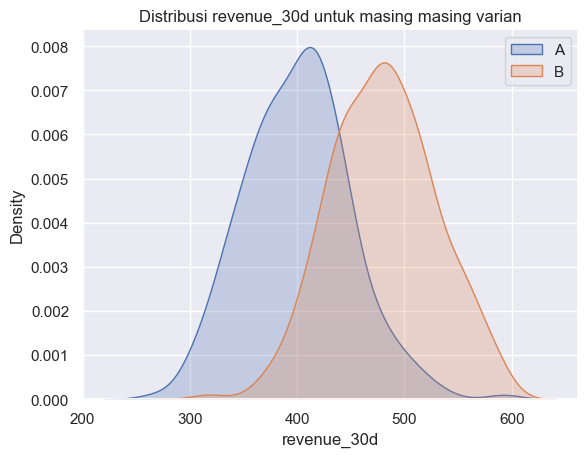

In [23]:
sns.kdeplot(data = var_a, fill=True)
sns.kdeplot(data = var_b, fill=True)
plt.title('Distribusi revenue_30d untuk masing masing varian')
plt.legend(['A', 'B'])
plt.show()

Hipotesis yang digunakan ialah: \
$H_0$ : revenue_30d varian B $\leq$ revenue_30d varian A \
$H_1$ : revenue_30d varian B $\gt$ revenue_30d varian A

In [24]:
stat, pval = ttest_ind(var_b, var_a, alternative = 'greater')

if pval < 0.05 :
  print('Tolak H0, Sehingga revenue_30d varian B > revenue_30d varian A')
else :
  print('Gagal Tolak H0, Sehingga revenue_30d varian B <=revenue_30d varian A')

Tolak H0, Sehingga revenue_30d varian B > revenue_30d varian A


# **4. Kesimpulan**
Berdasarkan hasil analisis disimpulkan bahwa
1. Secara statistik proporsi antara *trial_start* pengguna *flow+paywall copy baru* (Varian B) dengan varian(A) tidak signifikan dengan persentase perbedaan 9%.
2. Proporsi antara *paid_subscriber* pengguna *flow+paywall copy baru* (Varian B) dengan varian(A) tidak signifikan dengan persentase perbedaan 0.6%.
3. Pengguna *flow+paywall copy baru* (Varian B) meningkatkan revenue_30d